# **Project Name**    - Tesla Stock Price Prediction Using (SimpleRNN and LSTMs)

##### **Project Type**    - Basic Python, Data Visualization, Data Cleaning,EDA, NLP, Deep Learning (SimpleRNN and LSTM)

##### **Contribution**    - Individual/Team
##### **Team Member 1 - Naveen Rana**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Problem Summary**


**Problem Statement:**

Create a predictive DL model to predict the stock price of Tesla with following key points.

**Deep Learning Models:**

*    Stock Price data is sequential in nature and as you know Recurrent Neural Networks have worked very well on Sequential Data. Hence, explore deep learning approaches like Recurrent Neural Networks (RNNs), Long Short-Term Memory (LSTM) networks for the data and compare the performance.

*  You have to perform the analysis on the closing price. We are expecting you to create deep learning models (SimpleRNN and LSTM) that can predict 1 day, 5 days and 10 days behaviour of stock’s closing price

*    Analyze and handle missing values in the dataset (if any). How would you handle them differently for training the model having a time component in it ?

*   Use GridSearchCV to tune hyperparameters like the number of LSTM
units, dropout rate, and learning rate.



## ***1. Know Your Data***


### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd  # Data manipulation
import numpy as np  # Numerical operations
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns  # Advanced data visualization
import tensorflow as tf # Deep learning
import math # standard mathematical operations
from sklearn.metrics import mean_squared_error # evaluate the performance of predictive models.
import warnings  # Handling warnings
warnings.filterwarnings('ignore') # Suppress all warnings for clean output

### Dataset Loading

In [ ]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv('/content/drive/My Drive/Tesla stock price project/TSLA.csv')

Mounted at /content/drive


### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
shape = df.shape
print(f"Number of Rows  = {shape[0]}")
print(f"Number of Columns  = {shape[1]}")

Number of Rows  = 2416
Number of Columns  = 7


### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
print(f"Number of duplicate values = {df.duplicated().sum()}")

Number of duplicate values = 0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


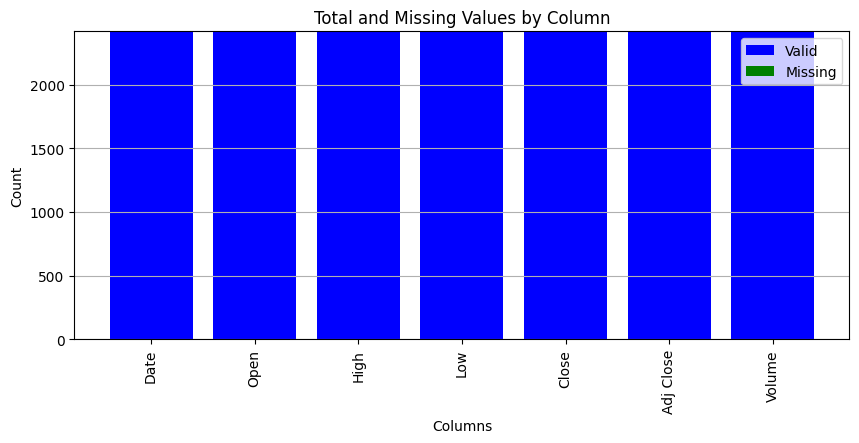

In [ ]:
# Visualizing the missing values
# Calculate total and missing counts for each column
total_counts = len(df)
missing_counts = df.isnull().sum()

# Calculate valid counts by subtracting missing from total
valid_counts = total_counts - missing_counts

# Plot the stacked bar chart for valid and missing values
plt.figure(figsize=(10, 4))
plt.bar(missing_counts.index, valid_counts, label='Valid', color='blue')  # Plot valid counts
plt.bar(missing_counts.index, missing_counts, bottom=valid_counts, label='Missing', color='green')  # Plot missing counts on top

# Add title and labels to the plot
plt.title('Total and Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Count')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.legend()  # Add a legend to differentiate between valid and missing
plt.grid(axis='y')  # Add horizontal grid lines

# Display the plot
plt.show()

### What did you know about your dataset?

*   The dataset loaded correctly.
*   Check column names.
*   Understand data types and values.
*   Quickly preview data structure.
*   Know the number of rows and columns.
*   Know the duplicate values.
*   Know the data types and missing values.
















## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns


Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
df.nunique()


,0
Date,2416
Open,2132
High,2128
Low,2136
Close,2225
Adj Close,2225
Volume,2391


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.

# Convert date columns to datetime type
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True, infer_datetime_format=True)
df.set_index('Date', inplace=True)
print(df.head())
print(df.index)

                 Open   High        Low      Close  Adj Close    Volume
Date                                                                   
2010-06-29  19.000000  25.00  17.540001  23.889999  23.889999  18766300
2010-06-30  25.790001  30.42  23.299999  23.830000  23.830000  17187100
2010-07-01  25.000000  25.92  20.270000  21.959999  21.959999   8218800
2010-07-02  23.000000  23.10  18.709999  19.200001  19.200001   5139800
2010-07-06  20.000000  20.00  15.830000  16.110001  16.110001   6866900
DatetimeIndex(['2010-06-29', '2010-06-30', '2010-07-01', '2010-07-02',
               '2010-07-06', '2010-07-07', '2010-07-08', '2010-07-09',
               '2010-07-12', '2010-07-13',
               ...
               '2020-01-21', '2020-01-22', '2020-01-23', '2020-01-24',
               '2020-01-27', '2020-01-28', '2020-01-29', '2020-01-30',
               '2020-01-31', '2020-02-03'],
              dtype='datetime64[ns]', name='Date', length=2416, freq=None)


### What all manipulations have you done and insights you found?

**Manipulations Done:-**

Convert the Date column to a datetime format and set it as the index.


## 4. ***Data Visualization***

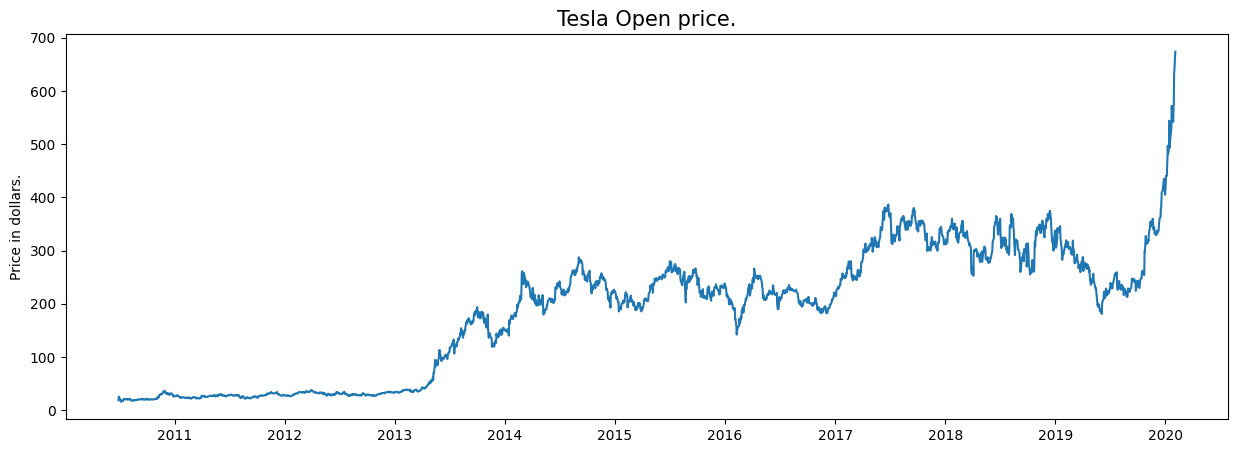

In [ ]:
# Chart 1- Tesla Open stock price Trend

plt.figure(figsize=(15,5))
plt.plot(df['Open'])
plt.title('Tesla Open price.', fontsize=15)
plt.ylabel('Price in dollars.')
plt.show()

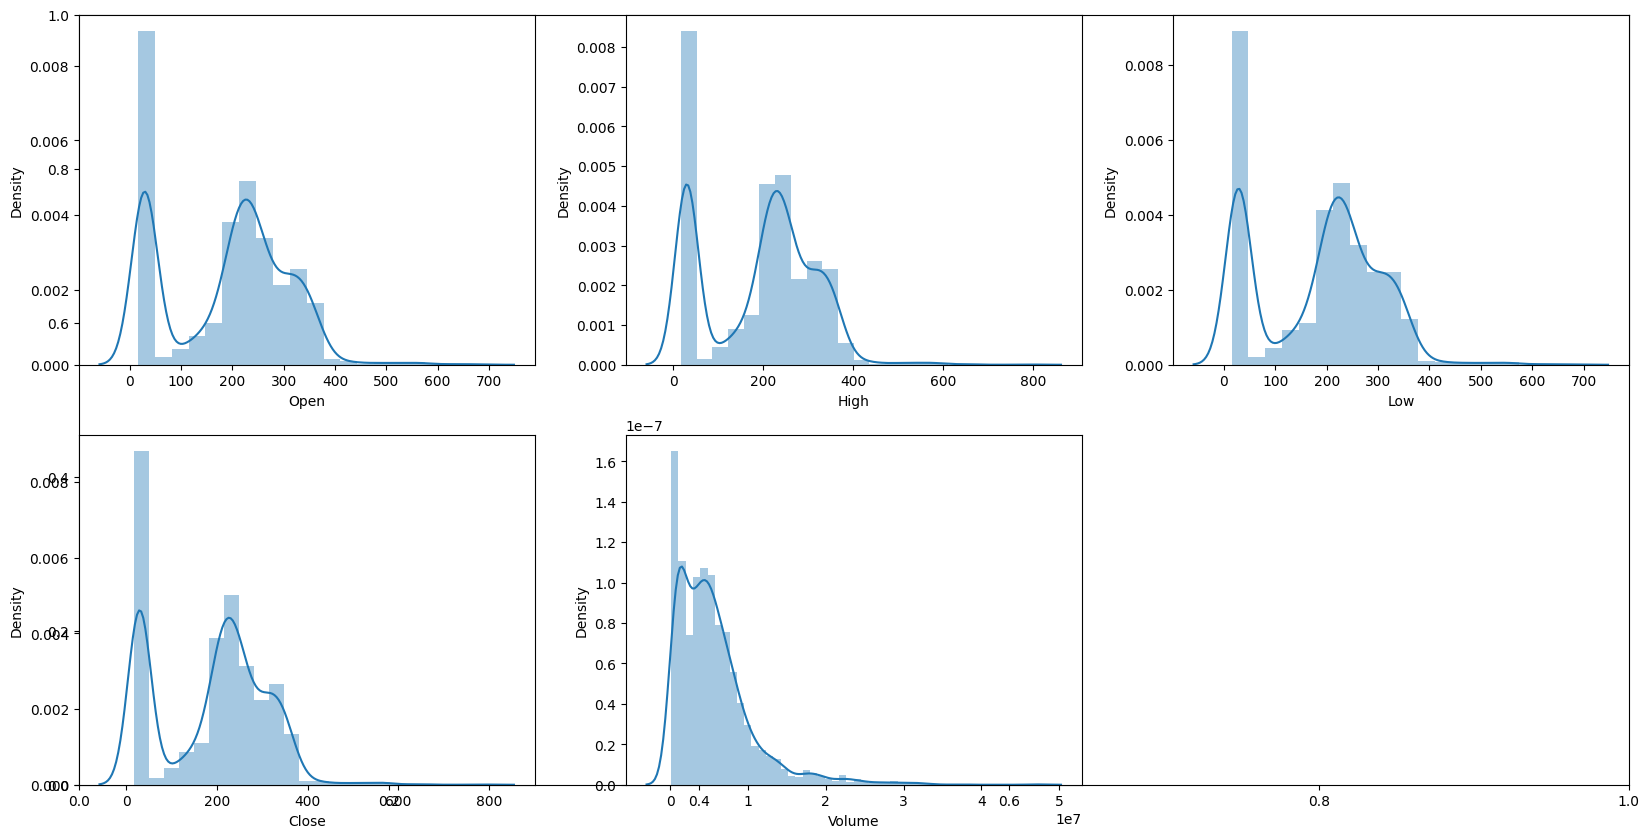

In [ ]:
# Chart 2- Distribution plot of continuous variables

features = ['Open', 'High', 'Low', 'Close', 'Volume']
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sns.distplot(df[col])
plt.show()

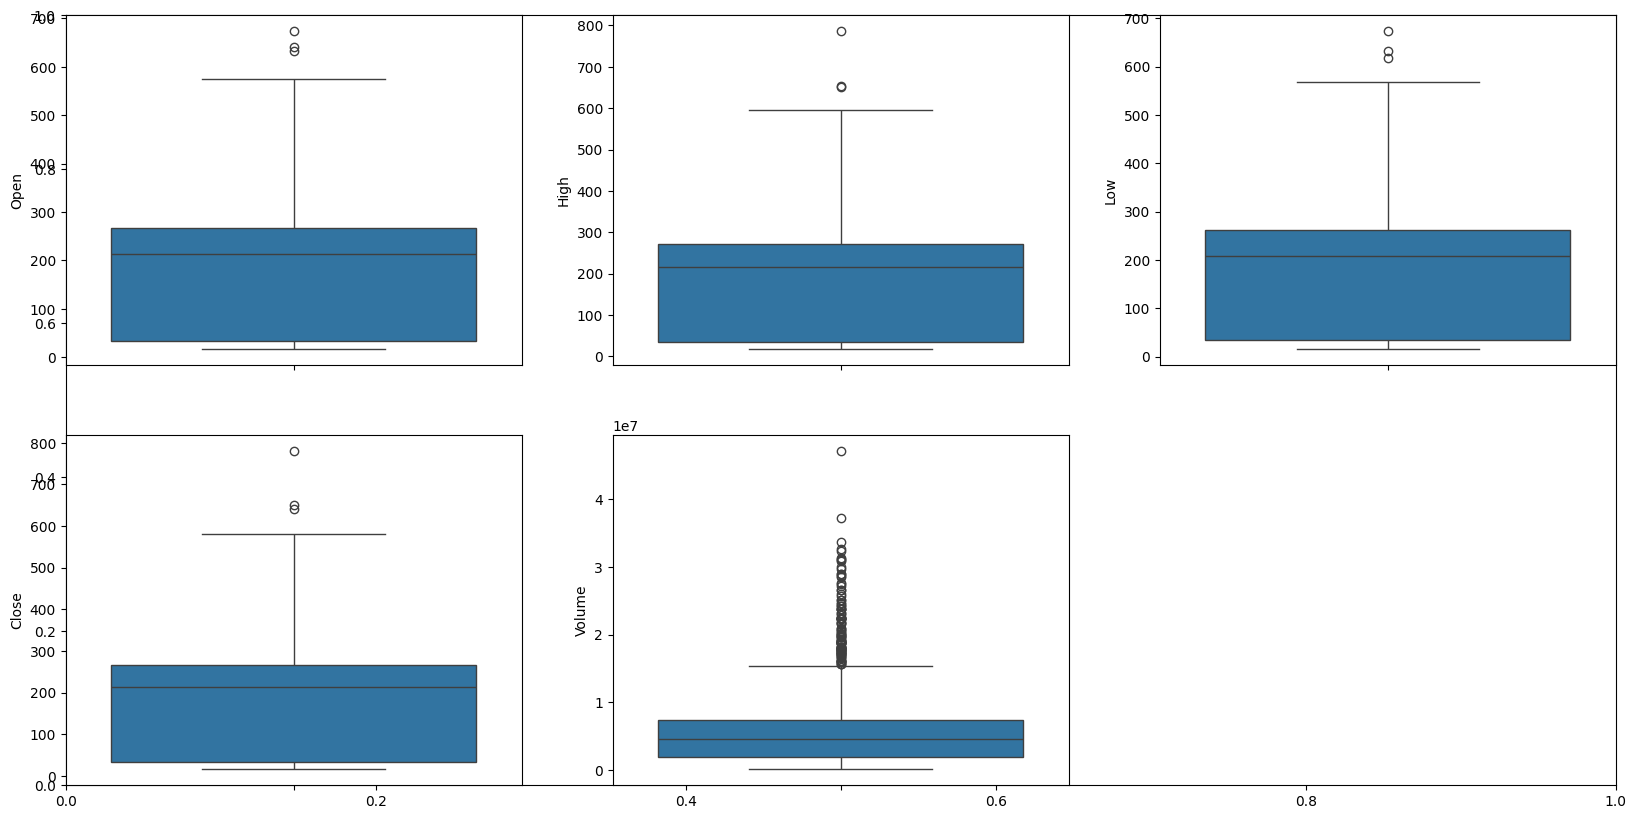

In [ ]:
# Chart 3- Box plot of continuous variables

plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sns.boxplot(df[col])
plt.show()

##  ***5. Scaling the Data***

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# We use only the 'Close' price as our feature for simplicity
data = df[['Close']].values

# Normalize the 'Close' prices using MinMaxScaler to fit the LSTM model
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)


In [ ]:
# Define a function to create Time-Series sequences from the dataset
def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - 1):
        a = dataset[i:(i + time_step), 0]  # Input data (features)
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])  # Output data (target)
    return np.array(dataX), np.array(dataY)

## ***6. Model Development***

##***Creating Simple RNN model***

In [ ]:
# Split the data into training and validation sets

train_length = round(len(df)*0.7)   # 70% train + 30% validation
lg = len(df)                        # rows that data has
val_length = lg-train_length

print('Total observations:',lg)
print('Training set:', train_length)
print('Validation set:', val_length)

Total observations: 2416
Training set: 1691
Validation set: 725


In [ ]:
train_data = df['Adj Close'][:train_length,]
train_data


,Adj Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001
...,...
2017-03-10,243.690002
2017-03-13,246.169998
2017-03-14,258.000000


In [ ]:
val_data = df['Adj Close'][train_length:,]
val_data

,Adj Close
Date,
2017-03-17,261.500000
2017-03-20,261.920013
2017-03-21,250.679993
2017-03-22,255.009995
2017-03-23,254.779999
...,...
2020-01-28,566.900024
2020-01-29,580.989990
2020-01-30,640.809998


In [ ]:
# Change 1d array to 2d array
# Changing shape from (1692,) to (1692,1)

train=train_data.values.reshape(-1,1)
train

array([[ 23.889999],
       [ 23.83    ],
       [ 21.959999],
       ...,
       [258.      ],
       [255.729996],
       [262.049988]])

In [ ]:
# Normalize the 'Adj Close' prices using MinMaxScaler to fit the RNN model
# Scale the data between the range [0,1]
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_trainset = scaler.fit_transform(train)
scaled_trainset

array([[0.02993635],
       [0.02971433],
       [0.02279455],
       ...,
       [0.89624035],
       [0.88784039],
       [0.91122698]])

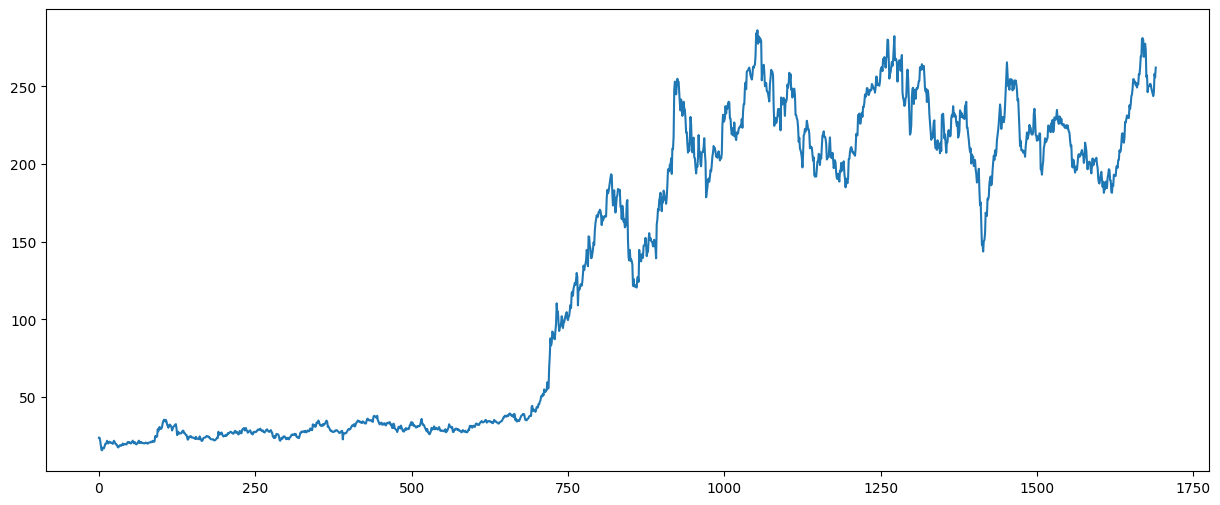

In [ ]:
plt.subplots(figsize = (15,6))
plt.plot(train)
plt.show()

In [ ]:
# Generate training and testing data with a specified time step
x_train = []
y_train = []
step = 50

for i in range(step, train_length):
    x_train.append(scaled_trainset[i-step:i,0])
    y_train.append(scaled_trainset[i,0])
X_train, y_train = np.array(x_train), np.array(y_train)  # convert list to array

print("Shape of X_train before reshape :",X_train.shape)
print("Shape of y_train before reshape :",y_train.shape)

Shape of X_train before reshape : (1641, 50)
Shape of y_train before reshape : (1641,)


In [ ]:
#Reshape array
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))
y_train.reshape(y_train.shape[0],1)


array([[0.01816903],
       [0.01617081],
       [0.01820603],
       ...,
       [0.89624035],
       [0.88784039],
       [0.91122698]])

In [ ]:
print("Shape of X_train after reshape :",X_train.shape)
print("Shape of y_train after reshape :",y_train.shape)

Shape of X_train after reshape : (1641, 50, 1)
Shape of y_train after reshape : (1641,)


In [ ]:
X_train[0].shape # Lets check the first row & shape of X_train


(50, 1)

In [ ]:
y_train[0]  # Check the first item in y_train

np.float64(0.018169030626401426)

In [ ]:
# import libraries
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import SimpleRNN
from keras.layers import Dropout

In [ ]:
# RNN model
model_rnn = Sequential()  # initializing the RNN

# adding first RNN layer and dropout regulatization
model_rnn.add(
    SimpleRNN(units = 50,return_sequences= True,input_shape = (X_train.shape[1],1)))

model_rnn.add(
    Dropout(0.2))

# adding second RNN layer and dropout regulatization
model_rnn.add(
    SimpleRNN(units = 50, return_sequences = True)
             )

model_rnn.add(
    Dropout(0.2)
             )

# adding third RNN layer and dropout regulatization
model_rnn.add(
    SimpleRNN(units = 50, return_sequences = True)
             )

model_rnn.add(
    Dropout(0.2)
             )


# adding fourth RNN layer and dropout regulatization
model_rnn.add(
    SimpleRNN(units = 50)
             )

model_rnn.add(
    Dropout(0.2)
             )

# adding the output layer
model_rnn.add(
    Dense(units = 1))

# Compile the model specifying the optimizer and loss function
model_rnn.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['accuracy'])


In [ ]:
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50, 50)         │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 50, 50)         │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,801 (69.54 KB)

 Trainable params: 17,801 (69.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model with the training data

# fitting the RNN
history = model_rnn.fit(X_train, y_train, epochs =50, batch_size =32)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 6.0938e-04 - loss: 0.3044
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.0000e+00 - loss: 0.1956
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.0000e+00 - loss: 0.1253
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 6.0938e-04 - loss: 0.0795
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 6.0938e-04 - loss: 0.0560
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.0000e+00 - loss: 0.0450
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 6.0938e-04 - loss: 0.0399
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 6.0938e-04 - loss: 0.0318
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 6.0938e-04 - loss: 0.0253
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 6.0938e-04 - loss: 0.0242
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 6.0938e-04 - loss: 0.0203
Epoch 12/50
52/52 ━

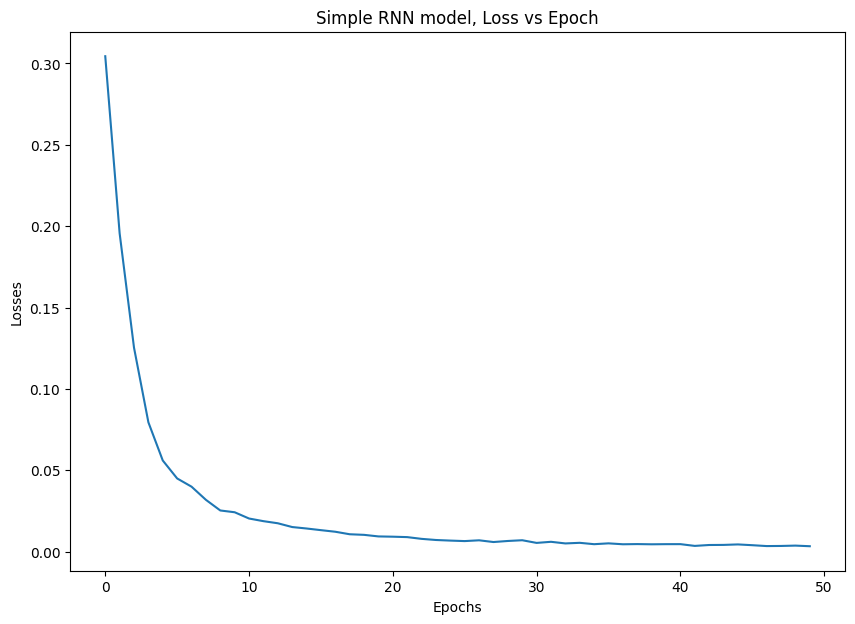

In [ ]:
# Plotting Loss vs Epochs

plt.figure(figsize =(10,7))
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.title("Simple RNN model, Loss vs Epoch")
plt.show()

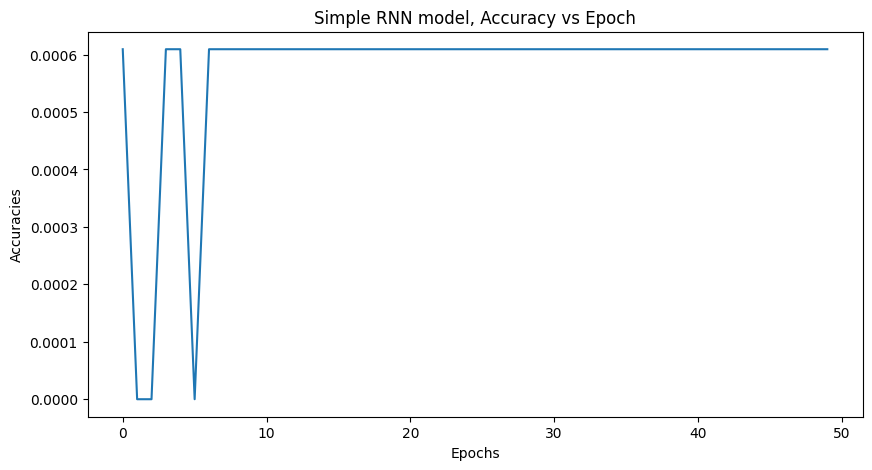

In [ ]:
# Plotting Accuracy vs Epochs

plt.figure(figsize =(10,5))
plt.plot(history.history['accuracy'])
plt.xlabel("Epochs")
plt.ylabel("Accuracies")
plt.title("Simple RNN model, Accuracy vs Epoch")
plt.show()

In [ ]:
# Model predictions for train data

y_pred = model_rnn.predict(X_train)   ## predictions
y_pred = scaler.inverse_transform(y_pred.reshape(1,-1))  # scaling back from 0-1 to original

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


In [ ]:
y_pred  # prediction array

array([[ 20.115868,  20.040323,  19.597878, ..., 252.25156 , 255.05655 ,
        256.96048 ]], dtype=float32)

In [ ]:
y_train = scaler.inverse_transform(y_train.reshape(1,-1))  # scaling back from 0-1 to original
y_train

array([[ 20.709999,  20.17    ,  20.719999, ..., 258.      , 255.729996,
        262.049988]])

In [ ]:
# y_train reshape

y_train.shape
y_train = np.reshape(y_train, (1641,1))

In [ ]:
#Prediction array reshape

y_pred.shape
y_pred = np.reshape(y_pred,(1641,1))

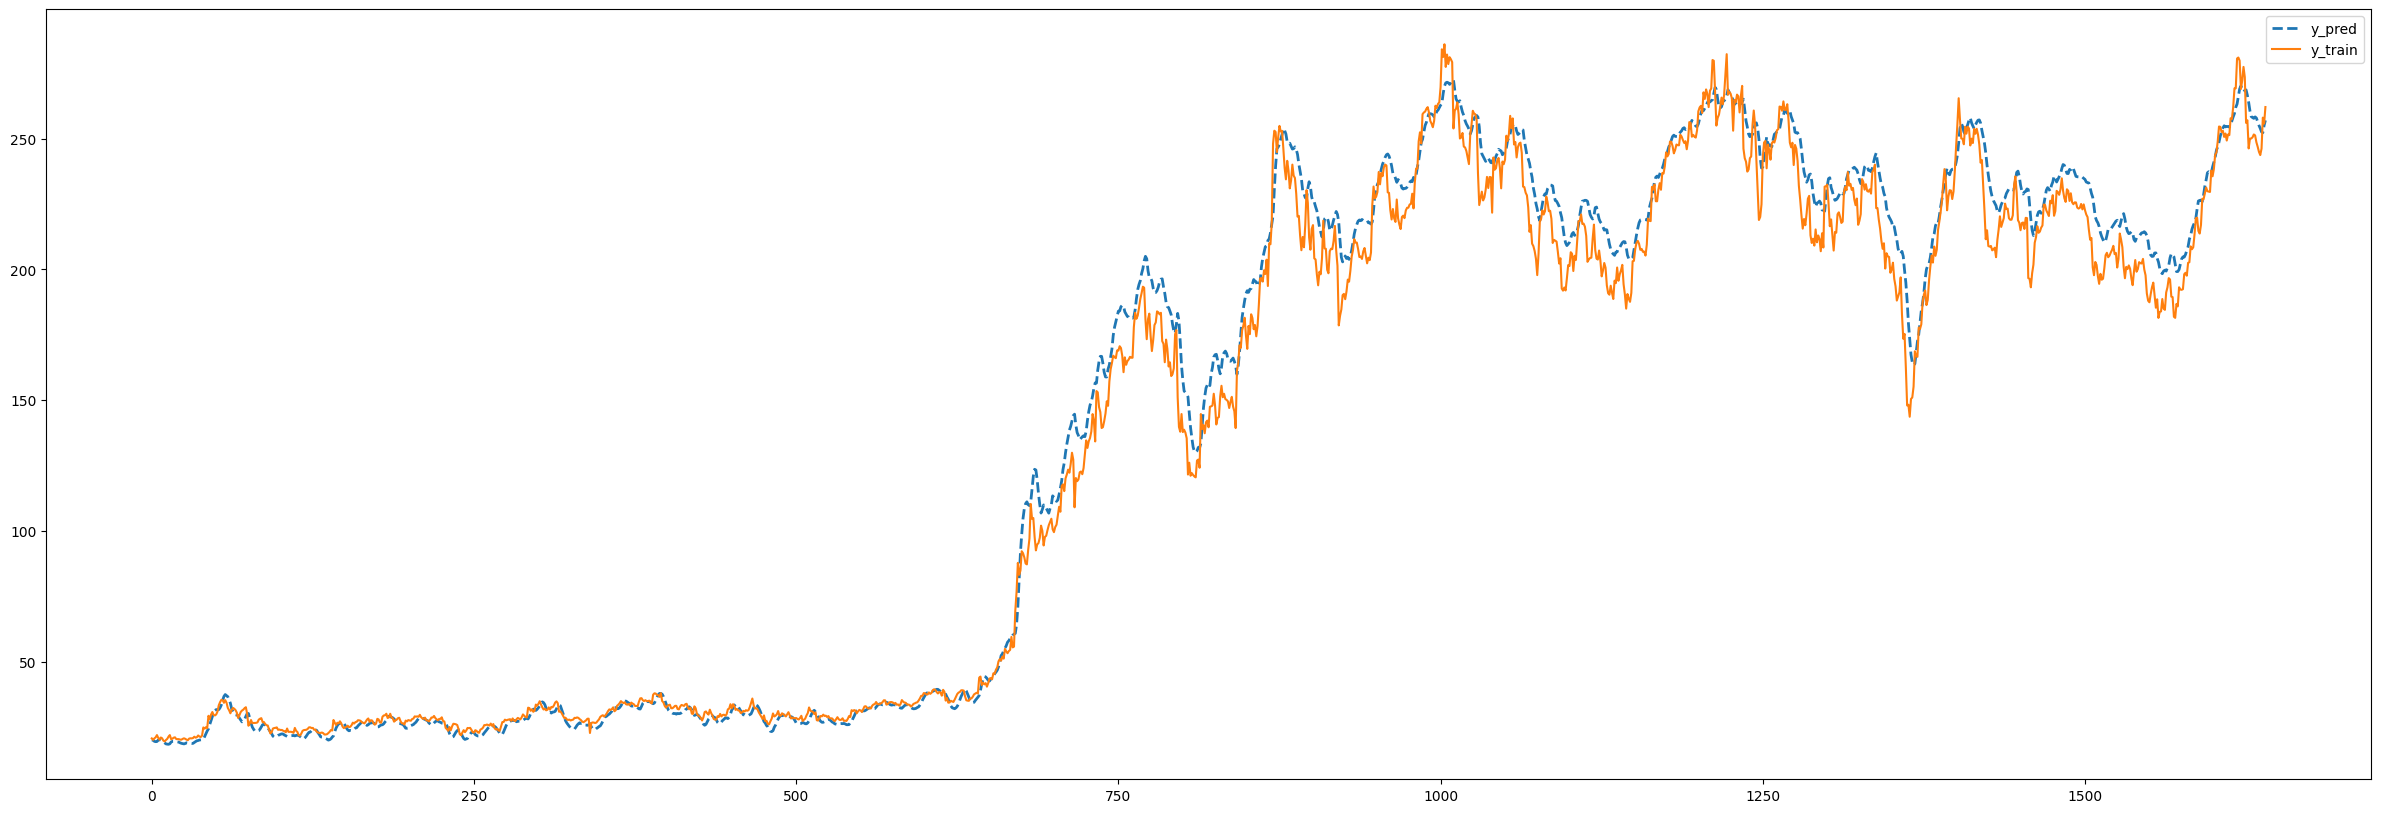

In [ ]:
plt.figure(figsize = (30,10))
plt.plot(y_pred, ls = '--', label = 'y_pred', lw = 2)
plt.plot(y_train, label = 'y_train')
plt.legend()
plt.show()

In [ ]:
val = val_data.values.reshape(-1,1)
val

array([[261.5     ],
       [261.920013],
       [250.679993],
       [255.009995],
       [254.779999],
       [263.160004],
       [270.220001],
       [277.450012],
       [277.380005],
       [277.920013],
       [278.299988],
       [298.519989],
       [303.700012],
       [295.      ],
       [298.700012],
       [302.540009],
       [312.390015],
       [308.709991],
       [296.839996],
       [304.      ],
       [301.440002],
       [300.25    ],
       [305.519989],
       [302.51001 ],
       [305.600006],
       [308.029999],
       [313.790009],
       [310.170013],
       [308.630005],
       [314.070007],
       [322.829987],
       [318.890015],
       [311.019989],
       [295.459991],
       [308.350006],
       [307.190002],
       [321.26001 ],
       [325.220001],
       [323.100006],
       [324.809998],
       [315.880005],
       [317.01001 ],
       [306.109985],
       [313.059998],
       [310.829987],
       [310.350006],
       [303.859985],
       [310.2

In [ ]:
scaled_valset = scaler.fit_transform(val)

In [ ]:
# Generate validation training data with a specified time step
xval_train = []
yval_train = []
step = 50

for i in range(step, val_length):
    xval_train.append(scaled_valset[i-step:i,0])
    yval_train.append(scaled_valset[i,0])

In [ ]:
X_val, y_val = np.array(xval_train), np.array(yval_train)

In [ ]:
X_val = np.reshape(X_val, (X_val.shape[0],X_val.shape[1],1))  # reshape to 3D array
y_val = np.reshape(y_val, (-1,1))

In [ ]:
y_pred_val = model_rnn.predict(X_val)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [ ]:
y_pred_val = scaler.inverse_transform(y_pred_val)
y_val_is = scaler.inverse_transform(y_val)

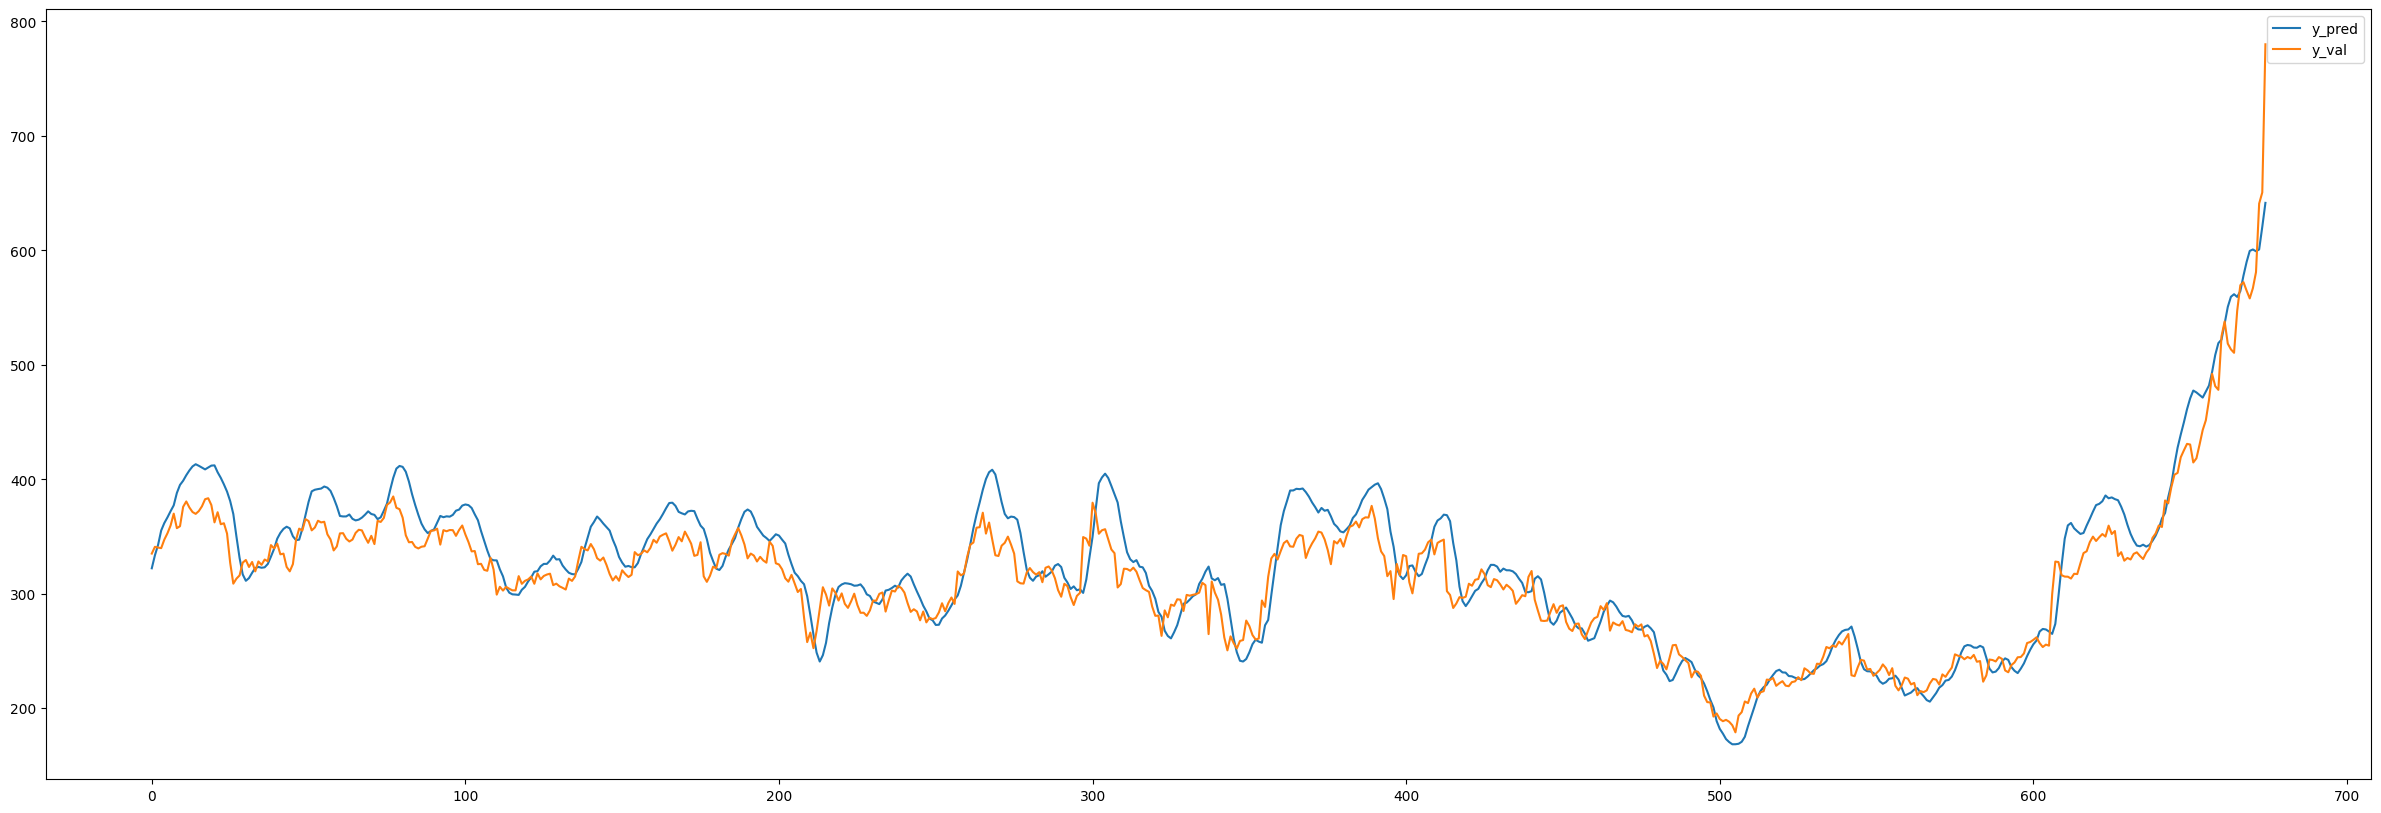

In [ ]:
plt.figure(figsize = (30,10))
plt.plot(y_pred_val, label = 'y_pred')
plt.plot(y_val_is, label = 'y_val')
plt.legend()
plt.show()

## ***Creating LSTM Model***

In [ ]:
# Split the data into training and test sets
training_size = int(len(data_scaled) * 0.70)  # 70% of data for training
test_size = len(data_scaled) - training_size  # Remaining data for testing
train_data, test_data = data_scaled[0:training_size, :], data_scaled[training_size:len(data_scaled), :]

# Generate training and testing data with a specified time step
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

# Reshape input to be [samples, time steps, features] which is required for LSTM models
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
y_test = y_test.reshape(y_test.shape[0], 1)

In [ ]:
# Build the LSTM model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(50, return_sequences=True, input_shape=(100, 1)),  # First LSTM layer
    tf.keras.layers.LSTM(50, return_sequences=False),  # Second LSTM layer
    tf.keras.layers.Dense(25),  # Dense layer with 25 neurons
    tf.keras.layers.Dense(1)  # Output layer with 1 neuron (prediction)
])

In [ ]:
# Compile the model specifying the optimizer and loss function
model.compile(optimizer='adam', loss='mean_squared_error',metrics = ['accuracy'])

In [ ]:
# Train the model with the training data
history1=model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=64, verbose=1)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.0000e+00 - loss: 1.6571e-04 - val_accuracy: 0.0000e+00 - val_loss: 0.0011
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.0000e+00 - loss: 1.5868e-04 - val_accuracy: 0.0000e+00 - val_loss: 0.0011
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.0000e+00 - loss: 1.5033e-04 - val_accuracy: 0.0000e+00 - val_loss: 0.0014
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - accuracy: 0.0000e+00 - loss: 1.4384e-04 - val_accuracy: 0.0000e+00 - val_loss: 0.0012
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.0000e+00 - loss: 1.4449e-04 - val_accuracy: 0.0000e+00 - val_loss: 0.0013
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.0000e+00 - loss: 1.3937e-04 - val_accuracy: 0.0000e+00 - val_loss: 0.0014
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.0000e+00 - loss: 1.3274e-04 - val_accuracy: 0.0000e+00 - val_loss: 9.8814e-04
Epoch 8/50
25/25 ━━━━

In [ ]:
# Make predictions on the training and test data
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [ ]:
# Inverse transform the predictions to original scale
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

In [ ]:
# Calculate and print RMSE for both training and test data
rmse_train = np.sqrt(mean_squared_error(y_train, train_predict))
rmse_test = np
print(f"Root Mean Squared Error (RMSE) for Training Data: {rmse_train}")

rmse_test = np.sqrt(mean_squared_error(y_test, test_predict))
print(f"Root Mean Squared Error (RMSE) for Test Data: {rmse_test}")

Root Mean Squared Error (RMSE) for Training Data: 301.2012763440259
Root Mean Squared Error (RMSE) for Test Data: 390.86468302562054


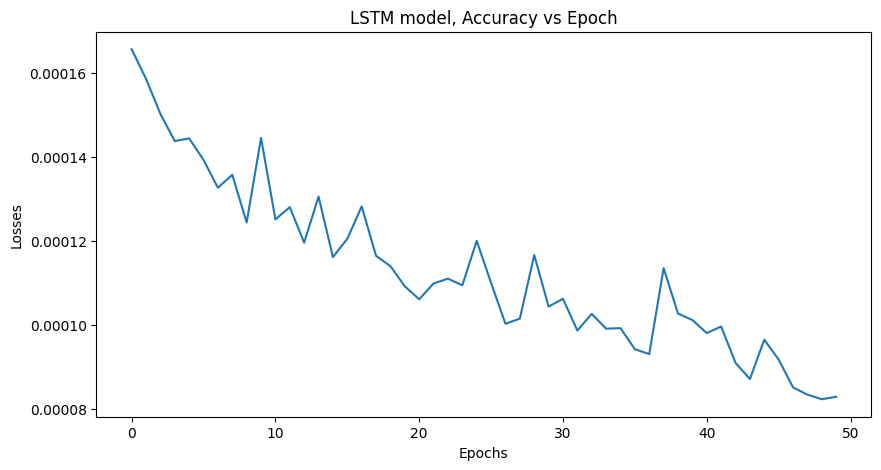

In [ ]:
plt.figure(figsize =(10,5))
plt.plot(history1.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.title("LSTM model, Accuracy vs Epoch")
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


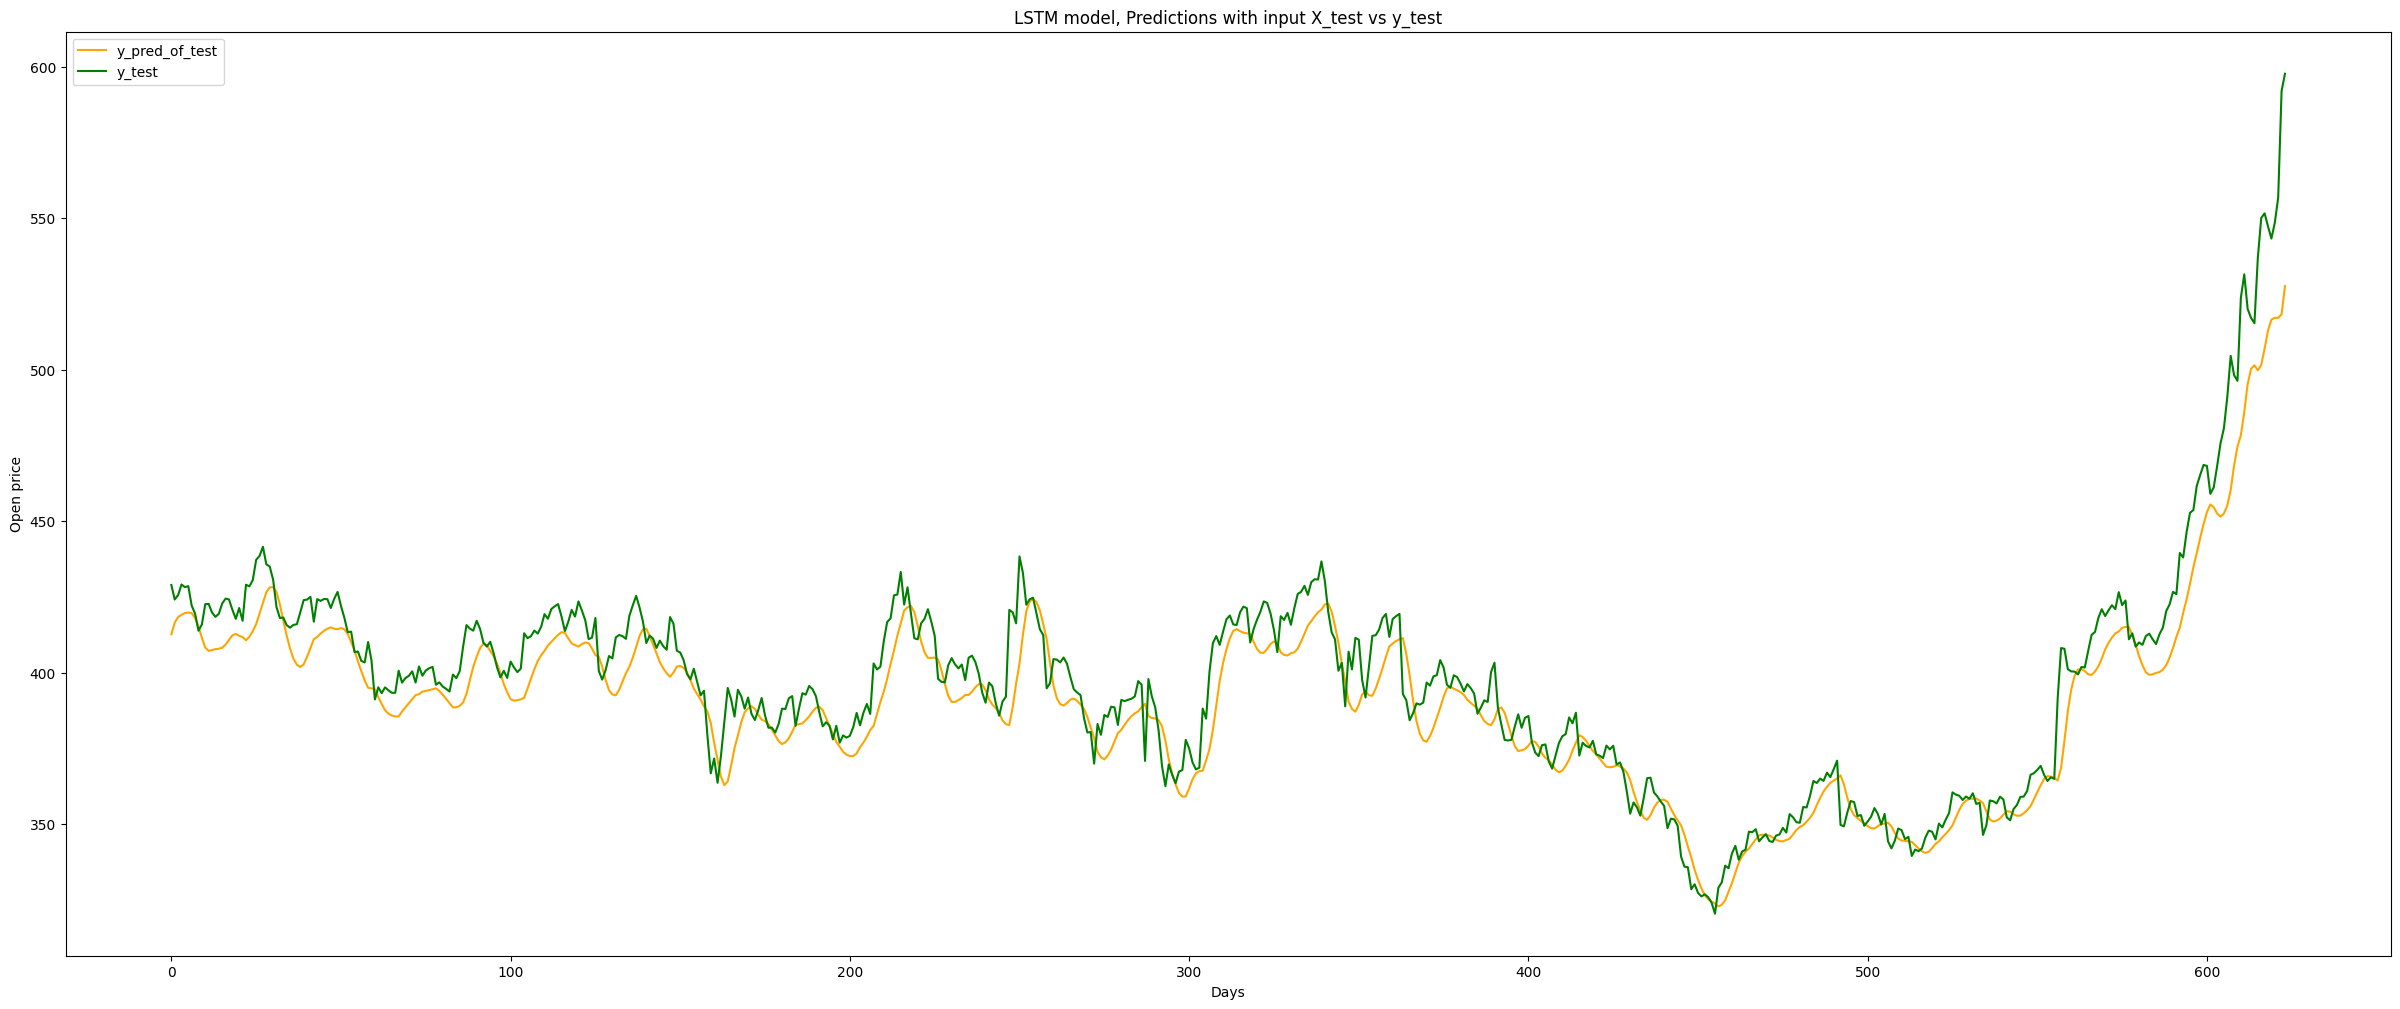

In [ ]:
plt.subplots(figsize =(30,12))
plt.plot(scaler.inverse_transform(model.predict(X_test)), label = "y_pred_of_test", c = "orange" )
plt.plot(scaler.inverse_transform((y_test)), label = "y_test", color = "g")
plt.xlabel("Days")
plt.ylabel("Open price")
plt.title("LSTM model, Predictions with input X_test vs y_test")
plt.legend()
plt.show()

## ***7. Future Price Prediction***

In [ ]:
df.iloc[-1]

,2020-02-03
Open,6.736900e+02
High,7.861400e+02
Low,6.735200e+02
Close,7.800000e+02
Adj Close,7.800000e+02
Volume,4.706500e+07


In [ ]:
X_input = df.iloc[-time_step:].Open.values               # getting last 100 rows and converting to array
X_input = scaler.fit_transform(X_input.reshape(-1,1))      # converting to 2D array and scaling
X_input = np.reshape(X_input, (1,100,1))                    # reshaping : converting to 3D array
print("Shape of X_input :", X_input.shape)
X_input

Shape of X_input : (1, 100, 1)


array([[[0.02854409],
        [0.05152183],
        [0.04987422],
        [0.04773674],
        [0.0398771 ],
        [0.04551021],
        [0.04773674],
        [0.04882775],
        [0.03437758],
        [0.03776191],
        [0.        ],
        [0.01358183],
        [0.03927593],
        [0.04105716],
        [0.03771737],
        [0.04170284],
        [0.01625365],
        [0.01569702],
        [0.01166701],
        [0.02518201],
        [0.03731661],
        [0.04613364],
        [0.05029723],
        [0.05196713],
        [0.07378713],
        [0.07309691],
        [0.08447443],
        [0.08046671],
        [0.07518979],
        [0.06626146],
        [0.06666222],
        [0.16433994],
        [0.16289271],
        [0.22928776],
        [0.21247744],
        [0.19691404],
        [0.1971367 ],
        [0.20430612],
        [0.20092176],
        [0.21165363],
        [0.20804667],
        [0.23285021],
        [0.24478436],
        [0.26582507],
        [0.27239328],
        [0

In [ ]:
simple_RNN_prediction = scaler.inverse_transform(model_rnn.predict(X_input))
LSTM_prediction = scaler.inverse_transform(model.predict(X_input))
print("Simple RNN, Open price prediction for 3/18/2017      :", simple_RNN_prediction[0,0])
print("LSTM prediction, Open price prediction for 3/18/2017 :", LSTM_prediction[0,0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Simple RNN, Open price prediction for 3/18/2017      : 629.09644
LSTM prediction, Open price prediction for 3/18/2017 : 592.4109
